    SEASON  OFF_RATING  DEF_RATING  NET_RATING  COVERAGE_PCT
0     2000   76.100900   90.881620  -14.776864          33.0
1     2001   84.602340   86.896679   -2.286415          57.5
2     2002   92.557882   87.065804    5.523848          51.6
3     2003  100.134245   92.223741    7.932815          64.0
4     2004   98.616792   88.825457    9.792896          71.9
5     2005   97.420655   93.319881    4.090536          63.4
6     2006  101.821060   92.993494    8.800537          53.5
7     2007  102.755149   91.943936   10.783352          62.5
8     2008   93.854444   85.594183    8.243595          55.5
9     2009   96.328773   90.520121    5.806288          71.8
10    2010  102.547222   93.580508    8.964595          76.8
11    2011   94.625257   89.838655    4.799160          81.4
12    2012   90.505126   92.196992   -1.703076          54.0
13    2013   94.853190   93.646220    1.202091          69.9
14    2014   92.003899   94.782832   -2.785021          54.4
15    2015   89.507051  

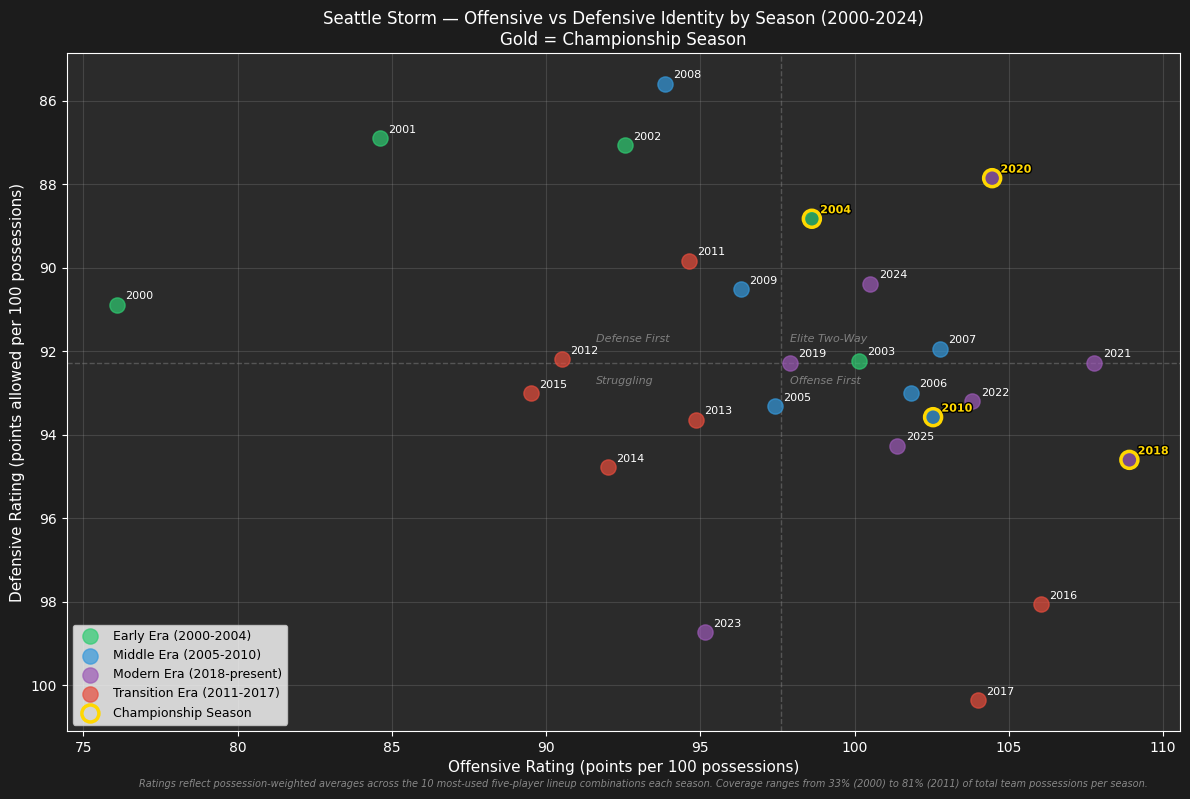

Saved to outputs/storm_identity_scatter.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
import os

# Championship years to highlight
championships = [2004, 2010, 2018, 2020]

# Load data
adv_df = pd.read_csv('../data/raw/storm_lineups_advanced.csv')

# Focus on key columns
df = adv_df[['SEASON', 'GROUP_NAME', 'MIN', 'GP', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'PACE', 'POSS']].copy()

# Get top 10 lineups by possessions for each season
top20 = (df.groupby('SEASON')
           .apply(lambda x: x.nlargest(20, 'POSS'))
           .reset_index(level=0)
           .reset_index(drop=True))

# Possession-weighted season summary from top 10
season_summary = top20.groupby('SEASON').apply(
    lambda x: pd.Series({
        'OFF_RATING': (x['OFF_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'DEF_RATING': (x['DEF_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'NET_RATING': (x['NET_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'TOTAL_POSS': x['POSS'].sum(),
        'LINEUP_COUNT': len(x)
    })
).reset_index()

# Coverage
total_poss_by_season = df.groupby('SEASON')['POSS'].sum()
filtered_poss_by_season = top20.groupby('SEASON')['POSS'].sum()
coverage = (filtered_poss_by_season / total_poss_by_season * 100).round(1)
coverage_df = coverage.reset_index()
coverage_df.columns = ['SEASON', 'COVERAGE_PCT']
season_summary = season_summary.merge(coverage_df, on='SEASON')

# Dynamic coverage range for footnote
min_cov = int(season_summary['COVERAGE_PCT'].min())
max_cov = int(season_summary['COVERAGE_PCT'].max())
min_cov_season = int(season_summary.loc[season_summary['COVERAGE_PCT'].idxmin(), 'SEASON'])
max_cov_season = int(season_summary.loc[season_summary['COVERAGE_PCT'].idxmax(), 'SEASON'])

print(season_summary[['SEASON', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'COVERAGE_PCT']])

os.makedirs('../outputs', exist_ok=True)
print(f"Season summary ready: {season_summary.shape}")

# Create era labels
def get_era(season):
    if season <= 2004:
        return 'Early Era (2000-2004)'
    elif season <= 2010:
        return 'Middle Era (2005-2010)'
    elif season <= 2017:
        return 'Transition Era (2011-2017)'
    else:
        return 'Modern Era (2018-present)'

season_summary['ERA'] = season_summary['SEASON'].apply(get_era)

era_colors = {
    'Early Era (2000-2004)': '#2ecc71',
    'Middle Era (2005-2010)': '#3498db',
    'Transition Era (2011-2017)': '#e74c3c',
    'Modern Era (2018-present)': '#9b59b6'
}

fig, ax = plt.subplots(figsize=(12, 8))

fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#2b2b2b')

ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Plot each era
for era, group in season_summary.groupby('ERA'):
    ax.scatter(
        group['OFF_RATING'],
        group['DEF_RATING'],
        c=era_colors[era],
        s=120,
        alpha=0.7,
        label=era,
        zorder=3
    )

# Label each point with season
for _, row in season_summary.iterrows():
    is_champ = row['SEASON'] in championships
    txt = ax.annotate(
        str(int(row['SEASON'])),
        (row['OFF_RATING'], row['DEF_RATING']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=8,
        fontweight='bold' if is_champ else 'normal',
        color='gold' if is_champ else 'white'
    )
    if is_champ:
        txt.set_path_effects([
            pe.withStroke(linewidth=2, foreground='black')
        ])

# Add championship markers
champ_data = season_summary[season_summary['SEASON'].isin(championships)]
ax.scatter(
    champ_data['OFF_RATING'],
    champ_data['DEF_RATING'],
    s=150,
    facecolors='none',
    edgecolors='gold',
    linewidths=2.5,
    zorder=4,
    label='Championship Season'
)

# Quadrant lines
avg_off = season_summary['OFF_RATING'].mean()
avg_def = season_summary['DEF_RATING'].mean()

ax.axvline(avg_off, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(avg_def, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
ax.text(avg_off + 0.3, avg_def - 0.5, 'Elite Two-Way', fontsize=8, color='gray', style='italic')
ax.text(avg_off - 6, avg_def - 0.5, 'Defense First', fontsize=8, color='gray', style='italic')
ax.text(avg_off + 0.3, avg_def + 0.5, 'Offense First', fontsize=8, color='gray', style='italic')
ax.text(avg_off - 6, avg_def + 0.5, 'Struggling', fontsize=8, color='gray', style='italic')

ax.invert_yaxis()

ax.set_xlabel('Offensive Rating (points per 100 possessions)', fontsize=11)
ax.set_ylabel('Defensive Rating (points allowed per 100 possessions)', fontsize=11)
ax.set_title('Seattle Storm — Offensive vs Defensive Identity by Season (2000-2024)\nGold = Championship Season', fontsize=12)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.2)

# Dynamic footnote
fig.text(
    0.12, 0.01,
    f'Ratings reflect possession-weighted averages across the 10 most-used five-player lineup combinations each season. '
    f'Coverage ranges from {min_cov}% ({min_cov_season}) to {max_cov}% ({max_cov_season}) of total team possessions per season.',
    fontsize=7,
    color='#888888',
    style='italic'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('../outputs/storm_identity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to outputs/storm_identity_scatter.png")

In [2]:
# Build tooltip text for each season
def build_tooltip(row):
    season = row['SEASON']
    coverage = row['COVERAGE_PCT']
    lineups = top20[top20['SEASON'] == season].nlargest(20, 'POSS')
    lines = [f"Top lineups {int(season)}:"]
    for i, (_, lineup_row) in enumerate(lineups.iterrows(), 1):
        lines.append(
            f"{i}. {lineup_row['GROUP_NAME']} "
            f"({int(lineup_row['POSS'])} poss, "
            f"NetRtg: {lineup_row['NET_RATING']:.1f})"
        )
    lines.append(f"<br><i>These 20 lineups represent {coverage}% of season possessions</i>")
    return '<br>'.join(lines)

season_summary['TOOLTIP'] = season_summary.apply(build_tooltip, axis=1)

In [9]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot each era
for era, group in season_summary.groupby('ERA'):
    is_champ = group['SEASON'].isin(championships)
    
    fig.add_trace(go.Scatter(
        x=group['OFF_RATING'],
        y=group['DEF_RATING'],
        mode='markers+text',
        name=era,
        marker=dict(
            color=era_colors[era],
            size=14,
            opacity=0.8
        ),
        text=group['SEASON'].astype(int).astype(str),
        textposition='top right',
        textfont=dict(
            color=['gold' if c else 'white' for c in is_champ],
            size=10
        ),
        hovertemplate='<b>%{customdata}</b><extra></extra>',
        customdata=group['TOOLTIP']
    ))

# Championship rings
fig.add_trace(go.Scatter(
    x=champ_data['OFF_RATING'],
    y=champ_data['DEF_RATING'],
    mode='markers',
    name='Championship Season',
    marker=dict(
        symbol='circle-open',
        size=22,
        color='gold',
        line=dict(width=2.5, color='gold')
    ),
    hoverinfo='skip'
))

# Quadrant lines
fig.add_hline(y=avg_def, line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=avg_off, line_dash='dash', line_color='gray', opacity=0.5)

# Quadrant labels
fig.add_annotation(x=avg_off + 0.3, y=avg_def - 0.5, text='Elite Two-Way',
    showarrow=False, font=dict(color='gray', size=9), xanchor='left')
fig.add_annotation(x=avg_off - 0.3, y=avg_def - 0.5, text='Defense First',
    showarrow=False, font=dict(color='gray', size=9), xanchor='right')
fig.add_annotation(x=avg_off + 0.3, y=avg_def + 0.5, text='Offense First',
    showarrow=False, font=dict(color='gray', size=9), xanchor='left')
fig.add_annotation(x=avg_off - 0.3, y=avg_def + 0.5, text='Struggling',
    showarrow=False, font=dict(color='gray', size=9), xanchor='right')

# Footnote
footnote = (f'Ratings reflect possession-weighted averages across the 20 most-used five-player lineup combinations each season. '
            f'Coverage ranges from {min_cov}% ({min_cov_season}) to {max_cov}% ({max_cov_season}) of total team possessions per season.')

fig.update_layout(
    title=dict(
        text='Seattle Storm — Offensive vs Defensive Identity by Season (2000-2025)<br><sup>Gold = Championship Season | Hover for top lineups</sup>',
        font=dict(color='white', size=14)
    ),
    xaxis=dict(
        title='Offensive Rating (points per 100 possessions)',
        color='white',
        gridcolor='#444444'
    ),
    yaxis=dict(
        title='Defensive Rating (points allowed per 100 possessions)',
        color='white',
        gridcolor='#444444',
        autorange='reversed'  # lower DEF_RATING is better
    ),
    plot_bgcolor='#2b2b2b',
    paper_bgcolor='#1c1c1c',
    font=dict(color='white'),
    legend=dict(
        font=dict(color='white'),
        bgcolor='#1c1c1c',
        bordercolor='#444444'
    ),
    annotations=[
        dict(
            text=footnote,
            xref='paper', yref='paper',
            x=0, y=-0.22,
            showarrow=False,
            font=dict(size=9, color='#888888'),
            xanchor='left',
            align='left'
        ),
        # Add to your annotations list in update_layout
        dict(
            text='Created by <b>Casey Steele</b>',
            xref='paper', yref='paper',
            x=1.0, y=-0.18,  # bottom right, same height as footnote
            showarrow=False,
            font=dict(size=9, color='#666666'),
            xanchor='right',
            align='right'
        )
    ],
    margin=dict(b=80)
)

# Save as interactive HTML
fig.write_html('../outputs/storm_identity_interactive.html')
fig.show()

print("Saved to ../outputs/storm_identity_interactive.html")

Saved to ../outputs/storm_identity_interactive.html


In [7]:
# what if we just did the top 10 most used lineups instead of 20+ possessions?
# Get top 10 lineups by possessions for each season
top20 = (df.groupby('SEASON')
           .apply(lambda x: x.nlargest(20, 'POSS'))
           .reset_index(drop=True))

# Check what the 10th lineup's possession count looks like each season
tenth = (df.groupby('SEASON')
           .apply(lambda x: x.nlargest(20, 'POSS').iloc[-1]['POSS'])
           .reset_index())
tenth.columns = ['SEASON', 'MIN_POSS_IN_TOP20']
print(tenth.to_string())

    SEASON  MIN_POSS_IN_TOP20
0     2000                 23
1     2001                 26
2     2002                 28
3     2003                 23
4     2004                 21
5     2005                 31
6     2006                 30
7     2007                 32
8     2008                 29
9     2009                 23
10    2010                 25
11    2011                 30
12    2012                 36
13    2013                 24
14    2014                 26
15    2015                 27
16    2016                 24
17    2017                 29
18    2018                 23
19    2019                 27
20    2020                 20
21    2021                 28
22    2022                 30
23    2023                 39
24    2024                 24
25    2025                 34


In [10]:
import shutil
shutil.copy(
    '../outputs/storm_identity_interactive.html',
    '../docs/storm_identity_interactive.html'
)
print("Copied to docs/")

Copied to docs/
